In [ ]:
#This project focuses on Data Immersion and Data Wrangling using the COVID-19 global dataset.
#Data Immersion refers to understanding the structure, features, and quality of the dataset in detail before analysis.
#Data Wrangling involves cleaning, transforming, and organizing raw data into a structured format suitable for analysis.

#In this project, we analyze COVID-19 data to:
#- Explore dataset structure
#- Handle missing and inconsistent values
#- Perform data cleaning operations
#- Transform and group data for analysis
#- Generate meaningful insights using visualization

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
print("Libraries Imported Successfully")

Libraries Imported Successfully


In [20]:
covid_df = pd.read_csv("G:/covid_19_clean_complete.csv/covid_19_clean_complete.csv")
country_df = pd.read_csv("G:/covid_19_clean_complete.csv/country_wise_latest.csv")
usa_country_wise_df = pd.read_csv("G:/covid_19_clean_complete.csv/usa_county_wise.csv")
day_wise_df=("G:\covid_19_clean_complete.csv\day_wise.csv")
grouped_df = pd.read_csv("G:/covid_19_clean_complete.csv/full_grouped.csv")
worldometer_df = pd.read_csv("G:/covid_19_clean_complete.csv/worldometer_data.csv")
print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [21]:
covid_df.shape

(49068, 10)

In [22]:
covid_df.columns

Index(['Province_State', 'Country_Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='str')

In [23]:
print("\nFirst 5 Rows:")
covid_df.head()


First 5 Rows:


,Province_State,Country_Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Unknown,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,Unknown,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,Unknown,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,Unknown,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,Unknown,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [24]:
print("\nDataset Information:")
covid_df.info()


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province_State  49068 non-null  str    
 1   Country_Region  49068 non-null  str    
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  str    
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 3.7 MB


In [25]:
print("\nMissing Values:")
covid_df.isnull().sum()


Missing Values:


Province_State    0
Country_Region    0
Lat               0
Long              0
Date              0
Confirmed         0
Deaths            0
Recovered         0
Active            0
WHO Region        0
dtype: int64

In [26]:
covid_df = covid_df.rename(columns={'Province/State': 'Province_State', 'Country/Region': 'Country_Region','Date': 'Date'})
covid_df['Date'] = pd.to_datetime(covid_df['Date'],errors='coerce')
covid_df['Province_State'] = covid_df['Province_State'].fillna('Unknown')
covid_df = covid_df.drop_duplicates()
print("Data Cleaning Completed")

Data Cleaning Completed


In [27]:
country_analysis = covid_df.groupby('Country_Region')[['Confirmed', 'Deaths', 'Recovered']].sum()
country_analysis = country_analysis.reset_index()
country_analysis = country_analysis.sort_values(by='Confirmed',ascending=False)
display(country_analysis.head(10))

,Country_Region,Confirmed,Deaths,Recovered
173,US,224345948,11011411,56353416
23,Brazil,89524967,3938034,54492873
138,Russia,45408411,619385,25120448
79,India,40883464,1111831,23783720
157,Spain,27404045,3033030,15093583
177,United Kingdom,26748587,3997775,126217
85,Italy,26745145,3707717,15673910
61,France,21210926,3048524,7182115
65,Germany,21059152,871322,17107839
81,Iran,19339267,1024136,15200895


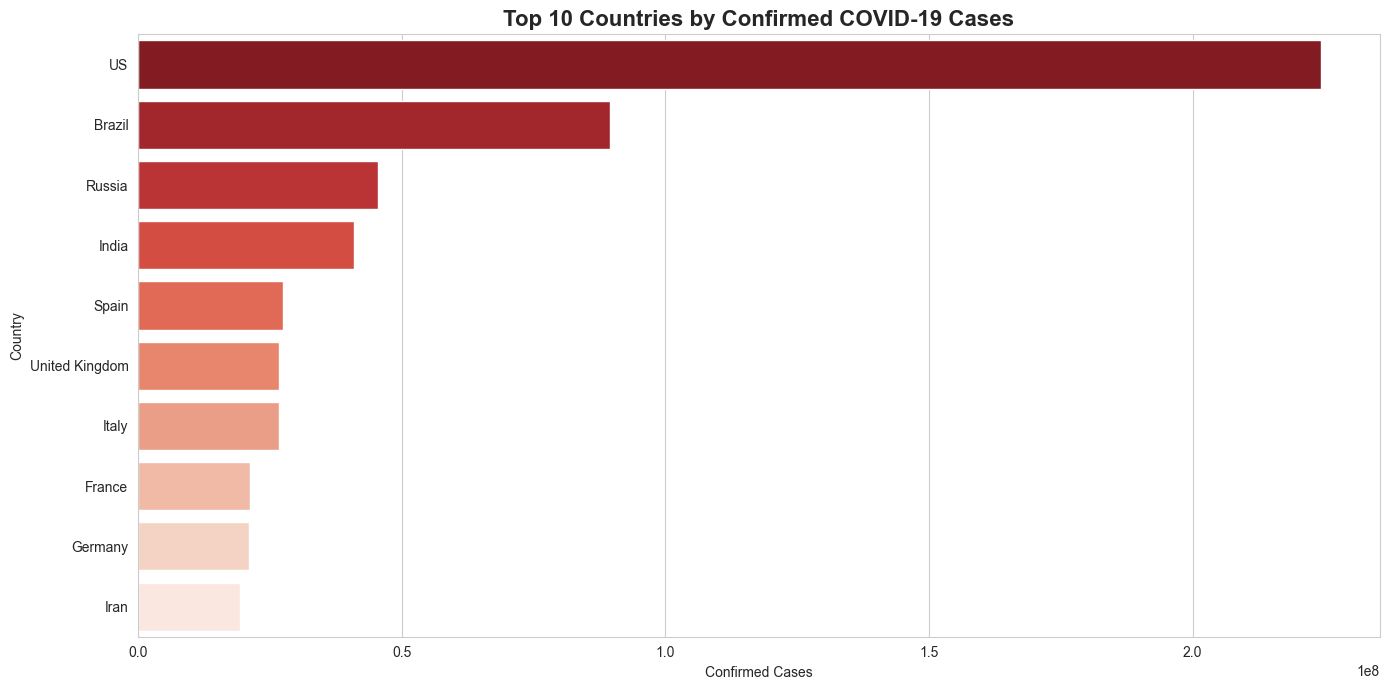

In [28]:
top10 = country_analysis.head(10)
plt.figure(figsize=(14,7))
sns.barplot(data=top10,x='Confirmed',y='Country_Region',palette='Reds_r')
plt.title('Top 10 Countries by Confirmed COVID-19 Cases',fontsize=16,fontweight='bold')
plt.xlabel('Confirmed Cases')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

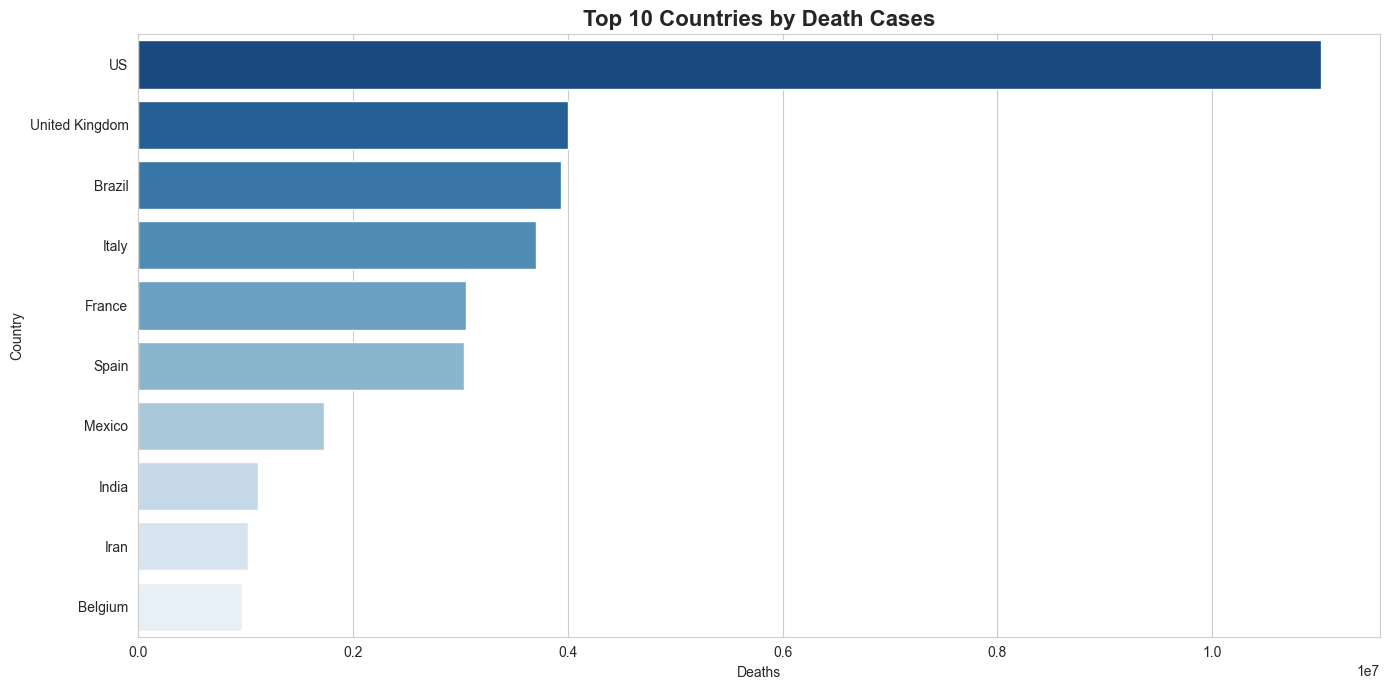

In [29]:
top_deaths = country_analysis.sort_values(by='Deaths',ascending=False).head(10)
plt.figure(figsize=(14,7))
sns.barplot(data=top_deaths,x='Deaths',y='Country_Region',palette='Blues_r')
plt.title('Top 10 Countries by Death Cases',fontsize=16,fontweight='bold')
plt.xlabel('Deaths')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

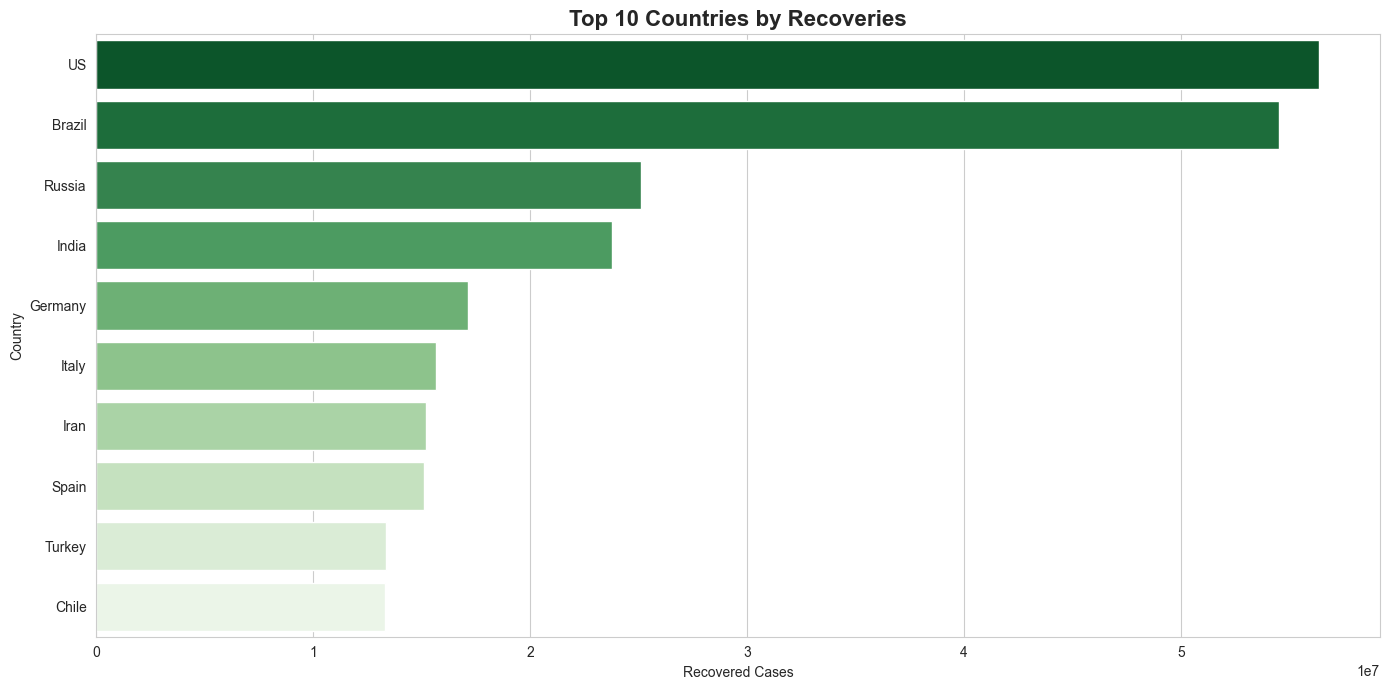

In [30]:
top_recovery = country_analysis.sort_values( by='Recovered',ascending=False).head(10)
plt.figure(figsize=(14,7))
sns.barplot(data=top_recovery,x='Recovered',y='Country_Region',palette='Greens_r')
plt.title('Top 10 Countries by Recoveries',fontsize=16,fontweight='bold')
plt.xlabel('Recovered Cases')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

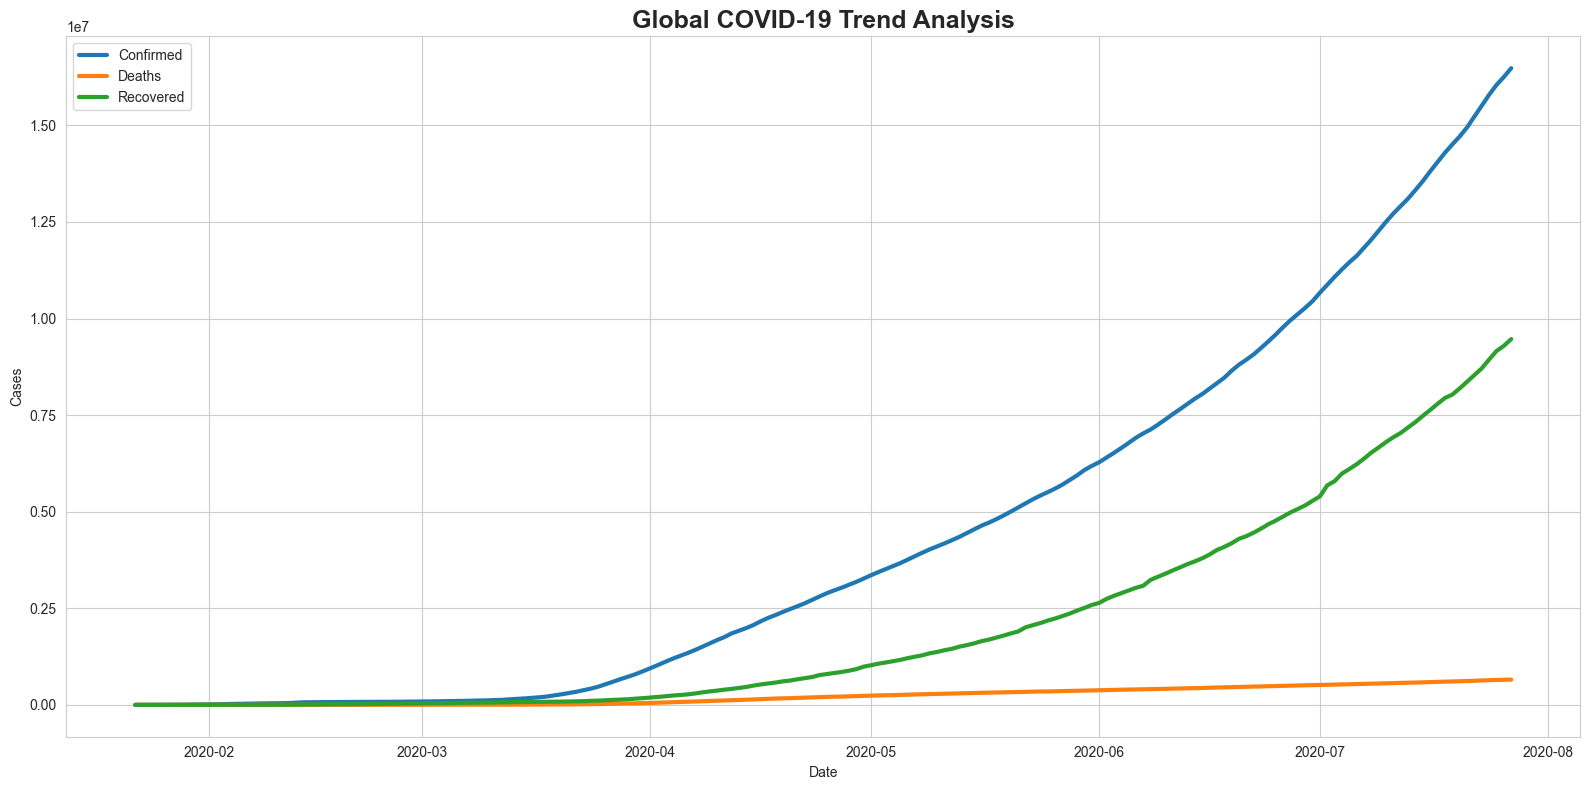

In [31]:
time_series = covid_df.groupby('Date')[['Confirmed', 'Deaths', 'Recovered']].sum()
plt.figure(figsize=(16,8))
plt.plot(time_series.index,time_series['Confirmed'],label='Confirmed',linewidth=3)
plt.plot(time_series.index,time_series['Deaths'],label='Deaths',linewidth=3)
plt.plot(time_series.index,time_series['Recovered'],label='Recovered',linewidth=3)
plt.title('Global COVID-19 Trend Analysis',fontsize=18,fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.tight_layout()
plt.show()

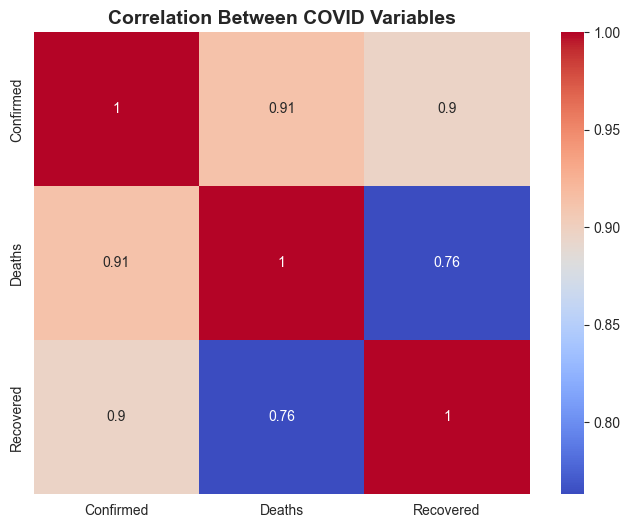

In [32]:
plt.figure(figsize=(8,6))
sns.heatmap(covid_df[['Confirmed', 'Deaths', 'Recovered']].corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Between COVID Variables',fontsize=14,fontweight='bold')
plt.show()

In [13]:
latest_cases = covid_df.groupby('Country_Region')[['Confirmed']].max().reset_index()
fig = px.choropleth(
    latest_cases,
    locations='Country_Region',
    locationmode='country names',
    color='Confirmed',
    hover_name='Country_Region',
    color_continuous_scale='Reds',
    title='Worldwide COVID-19 Confirmed Cases')
fig.show()

In [33]:
covid_df.to_csv("G:/covid_19_clean_complete.csv/covid_19_clean_complete.csv",index=False)
covid_df.head()

,Province_State,Country_Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Unknown,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,Unknown,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,Unknown,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,Unknown,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,Unknown,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [34]:
import os
os.makedirs("../outputs", exist_ok=True)
covid_df.to_csv("../outputs/covid_cleaned_final.csv",index=False)

In [35]:
import os
os.listdir("../outputs")

['cleaned_covid_data.csv', 'covid_cleaned_final.csv']

In [36]:
cleaned_data = pd.read_csv("../outputs/cleaned_covid_data.csv")
cleaned_data.head()

,Province_State,Country_Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Unknown,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,Unknown,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,Unknown,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,Unknown,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,Unknown,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [37]:
print("Total Confirmed Cases:")
covid_df['Confirmed'].sum()
print("\nTotal Death Cases:")
covid_df['Deaths'].sum()
print("\nTotal Recovered Cases:")
covid_df['Recovered'].sum()

Total Confirmed Cases:

Total Death Cases:

Total Recovered Cases:


np.int64(388408229)